In [1]:
import os

os.environ["OPENAI_API_KEY"] = "sk-19fe6b9376f8473bab1defd0bde82559"

In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="qwen3.5-plus",
    temperature=0,
    base_url="https://dashscope.aliyuncs.com/compatible-mode/v1",
)

TABLE_SETTINGS = {
    "vertical_strategy": "lines",
    "horizontal_strategy": "lines",
    "snap_tolerance": 3,
    "join_tolerance": 3,
    "intersection_tolerance": 3,
}

D:\Anaconda\envs\taidibei\lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.2.0)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(


In [3]:
import re
import pdfplumber
from langchain_core.documents import Document

def clean_text(text):
    text = re.sub(r'[ \t]+', ' ', text)      # 多空格
    text = re.sub(r'\n{3,}', '\n\n', text)   # 多换行
    return text.strip()

def extract_tables_from_pdf(pdf_path):
    table_docs = []

    with pdfplumber.open(pdf_path) as pdf:
        for page_idx, page in enumerate(pdf.pages):
            tables = page.extract_tables(TABLE_SETTINGS)
            if not tables:
                continue

            for table_idx, table in enumerate(tables):
                if not table or len(table) < 2:
                    continue

                # 第一行默认当表头
                headers = table[0]
                rows = table[1:]

                # 清洗表头
                headers = [str(h).strip() if h is not None else f"col_{i}" for i, h in enumerate(headers)]

                row_texts = []
                for row_id, row in enumerate(rows):
                    if not row:
                        continue

                    pairs = []
                    for h, v in zip(headers, row):
                        v = "" if v is None else str(v).strip()
                        if v:
                            pairs.append(f"{h}: {v}")

                    if pairs:
                        row_text = "；".join(pairs)
                        row_texts.append(f"第{row_id+1}行：{row_text}")

                if row_texts:
                    table_text = (
                        f"这是PDF第 {page_idx+1} 页的第 {table_idx+1} 个表格。\n"
                        + "\n".join(row_texts)
                    )

                    table_docs.append(
                        Document(
                            page_content=table_text,
                            metadata={
                                "source": pdf_path,
                                "page": page_idx + 1,
                                "type": "table",
                                "table_index": table_idx + 1,
                            },
                        )
                    )

    return table_docs


In [4]:
from langchain_community.document_loaders import PDFPlumberLoader, PyMuPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from tqdm import tqdm

pdf_folder = r"示例数据\附件5：研报数据"
docs = []

for file_name in os.listdir(pdf_folder):
    file_path = os.path.join(pdf_folder, file_name)
    
    if os.path.isdir(file_path):
        
        for pdf_name in os.listdir(file_path):
            pdf_path = os.path.join(file_path, pdf_name)
            
            loader = PyMuPDFLoader(pdf_path)
            docs.extend(loader.load())

            
print(docs[0].page_content)
print("-"*100)
print(docs[0].metadata)
        
for doc in docs:
    doc.page_content = clean_text(doc.page_content)

text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=1500, chunk_overlap=500
)

doc_splits = text_splitter.split_documents(docs)

请务必阅读正文后的重要声明部分 
 
1 
2025 年10 月29 日 
证券研究报告•2025 年三季报点评 
买入 （维持） 
 
当前价： 28.94 元 
华润三九（000999） 医药生物 
目标价： ——元（6 个月） 
内涵+外延双轮驱动，经营拐点已现 
投资要点 
西南证券研究院 
分析师：杜向阳 
执业证号：S1250520030002 
电话：021-68416017 
邮箱：duxy@swsc.com.cn 
联系人：王钰玮 
电话：021-68415819 
邮箱：wangyuwei@swsc.com.cn 
相对指数表现 
数据来源：聚源数据 
基础数据 
总股本(亿股) 
16.64 
流通A 股(亿股) 
16.63 
52 周内股价区间(元) 
27.30-37.35 
总市值(亿元) 
481.64 
总资产(亿元) 
386.98 
每股净资产(元) 
11.12 
相关研究 
1. 华润三九（000999）：业绩稳健增长，并
购整合持续推进  (2025-03-19) 
 
 事件：公司发布2025 年三季报。2025 年前三季度，公司实现营业收入219.9
亿元，同比+11.4%；归母净利润23.5 亿元，同比-20.5%；扣非归母净利润
为21.9 亿元，同比-20.6%。2025 年Q1/Q2/Q3 营收分别68.5/79.6/71.8 亿
元，分别同比-6%/+16.8%/+27.4%；归母净利润12.7/5.5/5.4 亿元，分别同
比-6.9%/-47.3%/-4.3%；扣非归母净利润12.2/4.8/4.9 亿元，分别同比
-8.3%/-51.1%/+10.1%，业绩符合预期。 
 内生业务环比增长，处方药逐步恢复。2025 年前三季度，公司实现营业收
入219.9 亿元，同比+11.4%；Q1/Q2/Q3 营收分别68.5/79.6/71.8 亿元，分
别同比-6%/+16.8%/+27.4%，其中内生业务三季度环比增长。1）CHC 领域，
呼吸品类受去年高基数与今年呼吸道疾病发病率回落影响，零售渠道自去年
年底起受政策影响呈阶段性调整。2）处方药已较好消化集采影响，逐步恢
复。天士力以处方药为核心，已完成百日融合，预计持续赋能。3）并表公
司昆药集团2025 前三季度营收显著下滑对公司收入产生影响。 


In [5]:
from langchain_milvus import Milvus
from langchain_community.embeddings import HuggingFaceBgeEmbeddings
from langchain_core.tools.retriever import create_retriever_tool

embeddings = HuggingFaceBgeEmbeddings(
    model_name="BAAI/bge-m3",
    model_kwargs={"device": "cuda"},
    encode_kwargs={
        "normalize_embeddings": True,
        "batch_size": 64,      # 视显存调整：16/32/64
        "show_progress_bar": True,
    },
)

vectorstore = Milvus.from_documents(
    documents=doc_splits,
    embedding=embeddings,
    connection_args={"host": "localhost", "port": "19530"},
    collection_name="my_docs",
    drop_old=True,
)

C:\Users\cr\AppData\Local\Temp\ipykernel_2136\2723386613.py:5: LangChainDeprecationWarning: The class `HuggingFaceBgeEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceBgeEmbeddings(
C:\Users\cr\AppData\Local\Temp\ipykernel_2136\2723386613.py:5: LangChainDeprecationWarning: `encode_kwargs['show_progress_bar']` was deprecated in LangChain 0.2.5 and will be removed in 1.0. Use the show_progress method on HuggingFaceBgeEmbeddings instead.
  embeddings = HuggingFaceBgeEmbeddings(


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [7]:
embeddings = HuggingFaceBgeEmbeddings(
    model_name="BAAI/bge-m3",
    model_kwargs={"device": "cuda"},
    encode_kwargs={"normalize_embeddings": True},
)

vectorstore = Milvus(
    embedding_function=embeddings,
    connection_args={"host": "localhost", "port": "19530"},
    collection_name="my_docs",
)

retriever = vectorstore.as_retriever(search_kwargs={"k": 5})

# retriever_tool = create_retriever_tool(
#     retriever,
#     "retrieve_pdf_file",
#     "Search and return information about AI agents, prompt engineering, and adversarial attacks on LLMs from Lilian Weng's blog posts.",
# ) 

# print(retriever_tool.invoke({"query": "2025年医保新增产品有哪些?"})[:1000])
texts = retriever.invoke("国家医保目录新增的中药产品有哪些")

for text in texts:
    print(text.page_content)
    print("-" * 50)

行业点评 
 
敬请参阅最后一页特别声明
扫码获取更多服务 
药物能够有效提升在患者中的渗透率。 
图表7：凭借商保，较高定价的药物能够实现患者渗透率的快速提升 
 
来源：insight，国金证券研究所 
中药经典名方申请较多，但政策鼓励创新方向明确。根据国家医保局25 年8 月公告，通过初步审查的中成药共23 种、
合计25 个产品。今日公示名单，最终入选7 个产品，包括4 个1 类新药以及3 个3 类新药。本次整体入选比例不高，
主要系经典名方申请较多，且多数未入选。通过初审名单中，共6 个1 类新药，最终入选4 个。12 个3 类中药，最终
入选3 个。6 个进口中药，无入选。1 个天然药物1.1 类，未入选。 
图表8：2025 年国家医保目录新增7 个中药产品 
 
来源：国家医保局，国金证券研究所 
投资建议 
西药：建议关注纳入新版医保目录创新药较多/品种重磅的恒瑞医药、百济神州、康方生物、科伦博泰、信达生物等，
以及大单品首次纳入医保的康诺亚（IL4 单抗）、特宝生物（长效生长激素）等。 
中成药：建议关注入选新版医保目录的中药产品放量潜力，如华润三九的益气清肺颗粒、以岭药业的芪防鼻通片、方
盛制药的养血祛风止痛颗粒、康缘药业的玉女煎颗粒/温阳解毒颗粒等。 
序号
公司
药品
2025年医保目录价格
2025年医保目录适应症
用法用量
注册分类
1
华润三九
益气清肺颗粒
13.60元(每袋装15g(相当
于饮片52g))
益气养阴，健脾和中，清热祛湿。适用于疫病后短期症状，
气阴两虚，脾虚失运，余邪未尽证，症见倦怠乏力、动后气
短、干咳少痰、咽喉不利、胃脘痞闷、纳呆便溏，舌淡或红
、少津，脉细数。
温水冲服。1次1袋，1
日2次。疗程14天。
中药3.2类
2
以岭药业
芪防鼻通片
--------------------------------------------------
行业点评 
 
敬请参阅最后一页特别声明
扫码获取更多服务 
 
凭借相关药物的医保准入，有望实现产品放量与市场份额的快速提升。本轮医保谈判中西药涉及的107 个品类，
合计116 款药物（部分同一品类有多家药企入选）。其中恒瑞医药合计11 款新药首次纳入医保目录，其次是阿斯
利康合计纳入4 款，正大天晴、科伦博泰、礼来制药、齐鲁制药、罗氏制药则分别成功纳入3 款药

In [8]:
retriever_tool = create_retriever_tool(
    retriever,
    "retrieve_pdf_file",
    "Search and return information from the internal knowledge base.",
) 

In [9]:
import pandas as pd
from sqlalchemy import create_engine
from langchain_community.utilities import SQLDatabase
from langchain_community.agent_toolkits import SQLDatabaseToolkit

engine = create_engine("sqlite:///example.db")

sheets = pd.read_excel(
    r"D:\桌面\文件夹\泰迪杯\B题-示例数据\示例数据\附件2：财务报告\深交extract_result.xlsx",
    sheet_name=None,
    engine="openpyxl"
)

for sheet_name, df in sheets.items():
    table_name = sheet_name.strip().replace(" ", "_").replace("-", "_")
    df.to_sql(table_name, con=engine, if_exists="replace", index=False)

db = SQLDatabase.from_uri("sqlite:///example.db")
print(db.get_usable_table_names())

['balance', 'cash', 'core', 'income', 'other']


In [10]:
import os
import requests, pathlib
from langchain_community.utilities import SQLDatabase
from langchain_community.agent_toolkits import SQLDatabaseToolkit
from langchain_openai import ChatOpenAI

from typing import Literal

from langchain.messages import AIMessage
from langchain_core.runnables import RunnableConfig
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.prebuilt import ToolNode

In [11]:
toolkit = SQLDatabaseToolkit(db=db, llm=llm)
tools = toolkit.get_tools()

get_schema_tool = next(tool for tool in tools if tool.name == "sql_db_schema")
get_schema_node = ToolNode([get_schema_tool], name="get_schema")

run_query_tool = next(tool for tool in tools if tool.name == "sql_db_query")
run_query_node = ToolNode([run_query_tool], name="run_query")

In [12]:
def list_tables(state: MessagesState):
    tool_call = {
        "name": "sql_db_list_tables",
        "args": {},
        "id": "abc123",
        "type": "tool_call",
    }
    tool_call_message = AIMessage(content="", tool_calls=[tool_call])

    list_tables_tool = next(tool for tool in tools if tool.name == "sql_db_list_tables")
    tool_message = list_tables_tool.invoke(tool_call)
    response = AIMessage(f"Available tables: {tool_message.content}")

    return {"messages": [tool_call_message, tool_message, response]}


def call_get_schema(state: MessagesState):
    llm_with_tools = llm.bind_tools([get_schema_tool], tool_choice="auto")
    response = llm_with_tools.invoke(state["messages"])

    return {"messages": [response]}


generate_query_system_prompt = """
You are an agent designed to interact with a SQL database.
Given an input question, create a syntactically correct {dialect} query to run,
then look at the results of the query and return the answer. Unless the user
specifies a specific number of examples they wish to obtain, always limit your
query to at most {top_k} results.

You can order the results by a relevant column to return the most interesting
examples in the database. Never query for all the columns from a specific table,
only ask for the relevant columns given the question.

DO NOT make any DML statements (INSERT, UPDATE, DELETE, DROP etc.) to the database.
""".format(
    dialect=db.dialect,
    top_k=5,
)


def generate_query(state: MessagesState):
    system_message = {
        "role": "system",
        "content": generate_query_system_prompt,
    }
    # 我们在这里不强制工具调用，以允许模型在获得解决方案时自然响应
    llm_with_tools = llm.bind_tools([run_query_tool])
    response = llm_with_tools.invoke([system_message] + state["messages"])

    return {"messages": [response]}


check_query_system_prompt = """
You are a SQL expert with a strong attention to detail.
Double check the {dialect} query for common mistakes, including:
- Using NOT IN with NULL values
- Using UNION when UNION ALL should have been used
- Using BETWEEN for exclusive ranges
- Data type mismatch in predicates
- Properly quoting identifiers
- Using the correct number of arguments for functions
- Casting to the correct data type
- Using the proper columns for joins

If there are any of the above mistakes, rewrite the query. If there are no mistakes,
just reproduce the original query.

You will call the appropriate tool to execute the query after running this check.
""".format(dialect=db.dialect)


def check_query(state: MessagesState):
    system_message = {
        "role": "system",
        "content": check_query_system_prompt,
    }

    # 生成一个人工用户消息来检查
    tool_call = state["messages"][-1].tool_calls[0]
    user_message = {"role": "user", "content": tool_call["args"]["query"]}
    llm_with_tools = llm.bind_tools([run_query_tool], tool_choice="auto")
    response = llm_with_tools.invoke([system_message, user_message])
    response.id = state["messages"][-1].id

    return {"messages": [response]}

In [13]:
def should_continue(state: MessagesState) -> Literal[END, "check_query"]:
    messages = state["messages"]
    last_message = messages[-1]
    if not last_message.tool_calls:
        return END
    else:
        return "check_query"

builder = StateGraph(MessagesState)
builder.add_node(list_tables)
builder.add_node(call_get_schema)
builder.add_node(get_schema_node, "get_schema")
builder.add_node(generate_query)
builder.add_node(check_query)
builder.add_node(run_query_node, "run_query")

builder.add_edge(START, "list_tables")
builder.add_edge("list_tables", "call_get_schema")
builder.add_edge("call_get_schema", "get_schema")
builder.add_edge("get_schema", "generate_query")
builder.add_conditional_edges(
    "generate_query",
    should_continue,
)
builder.add_edge("check_query", "run_query")
builder.add_edge("run_query", "generate_query")

sql_graph = builder.compile()

In [14]:
from pydantic import BaseModel, Field
from typing import Literal
from langchain_core.messages import HumanMessage

def get_current_user_query(state):
    for msg in reversed(state.get("messages", [])):
        if isinstance(msg, HumanMessage):
            return msg.content
        if getattr(msg, "type", None) == "human":
            return msg.content
        if getattr(msg, "role", None) == "user":
            return msg.content

    return state.get("query", "")

# def generate_query_or_respond(state: MessagesState):
#     response = llm.bind_tools([retriever_tool]).invoke(state["messages"]) # bind_tool将该工具注册到LLM上
#     return {"messages": [response]}

# test_state = {"messages": [{"role": "user", "content": "Hello!"}]}
# result = generate_query_or_respond(test_state)
# print("Response to greeting:", result["messages"][-1].content)

# test_state = {
#     "messages": [
#         {
#             "role": "user",
#             "content": "What is Chain of Thought prompting and how does it work?",
#         }
#     ]
# }
# result = generate_query_or_respond(test_state)
# if hasattr(result["messages"][-1], "tool_calls") and result["messages"][-1].tool_calls:
#     print("Model decided to use retrieval tool")
#     print("Tool call:", result["messages"][-1].tool_calls[0])

In [15]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import ToolNode, tools_condition
from typing import List, Dict, Any, Literal
from pydantic import BaseModel, Field

class SubTask(BaseModel):
    type: Literal["sql", "rag"]
    goal: str

class RouteDecision(BaseModel):
    route: Literal["sql", "rag", "hybrid", "clarify"]
    reason: str
    missing_slots: List[str] = []
    subtasks: List[SubTask] = []

class ParentState(MessagesState, total=False):
    query: str

    route: str
    reason: str
    missing_slots: List[str]
    subtasks: List[SubTask]

    need_sql: bool
    need_rag: bool
    need_clarification: bool

    sql_result: dict
    rag_result: dict

    final_answer: str

In [16]:
def generate(state: MessagesState):
    print("---GENERATE ANSWER---")

    question = get_current_user_query(state)
    docs = state["messages"][-1].content

    rag_prompt = f"""You are an assistant for question-answering tasks.

        Use the following pieces of retrieved context to answer the question.

        If you don't know the answer, just say that you don't know.

        Use three sentences maximum and keep the answer concise.

        Question: {question}

        Context: {docs}

        Answer:"""

    response = llm.invoke([{"role": "user", "content": rag_prompt}])

    return {
        "messages": [response],
        "final_answer": response.content,
    }

# def generate(state: MessagesState):
#     print("---GENERATE ANSWER---")

#     question = get_current_user_query(state)
#     docs = state["messages"][-1].content

#     rag_prompt = f"""You are an assistant for question-answering tasks.

#         Use the following pieces of retrieved context to answer the question.

#         If you don't know the answer, just say that you don't know.

#         Use three sentences maximum and keep the answer concise.

#         Question: {question}

#         Context: {docs}

#         Answer:"""

#     response = llm.invoke([{"role": "user", "content": rag_prompt}])

#     return {"messages": [response]}

In [17]:
# class RouteDecision(BaseModel):
#     route: Literal["sql", "rag", "hybrid", "clarify"] = Field(
#         description="路由类型"
#     )
#     reason: str = Field(description="路由原因")
#     missing_slots: List[str] = Field(default_factory=list, description="缺失槽位")
#     subtasks: List[str] = Field(default_factory=list, description="拆解后的子任务")

def route_node(state):
#     question = state["messages"][0].content
    question = get_current_user_query(state)
    
    route_prompt = f"""
    
    你是一个上市公司财报智能问数助手的“路由器（Router）”。

    你的任务不是回答用户问题，而是判断这个问题应该走哪条处理链路。

    你只能输出以下四种 route：
    1. sql
       - 适用于可以主要通过结构化财务数据库回答的问题
       - 典型包括：数值查询、指标查询、同比/环比、趋势、排名、topN、筛选、排序、聚合统计、跨公司比较
    2. rag
       - 适用于需要主要依赖非结构化文本知识库回答的问题
       - 典型包括：原因分析、政策解读、研报观点、公告理解、行业判断、风险分析、管理层表述、市场预期
    3. hybrid
       - 适用于同时需要结构化数据库 + 非结构化知识库的问题
       - 例如：先查财务数据，再解释原因；先找top企业，再分析背后驱动
    4. clarify
       - 适用于用户问题缺少关键条件，当前无法可靠执行
       - 例如缺少公司名、报告期、指标名、比较对象等
    
    判定原则：
    - 如果问题主要在问“多少、是否、排名、变化趋势、同比环比、topN、哪个最大/最小”，优先判为 sql
    - 如果问题主要在问“为什么、原因、影响、怎么看、风险、政策、研报怎么说”，优先判为 rag
    - 如果问题同时包含“查数据 + 做解释/归因/结合研报”，判为 hybrid
    - 如果问题缺少关键查询条件，判为 clarify

    请特别注意：
    - 不要因为问题里出现“分析”两个字就一律归为 rag
    - “趋势分析”“同比分析”“排名分析”通常仍然属于 sql
    - “原因分析”“政策影响分析”“研报观点分析”通常属于 rag
    - “数据趋势 + 原因解释”属于 hybrid
    - 若问题中有多个子任务，先判断每个子任务是否分别依赖结构化数据或非结构化文本；只有同时存在至少一个 sql 子任务和至少一个 rag 子任务时，整体 route 才判为 hybrid。
    
    示例1
    用户问题：比亚迪2025年三季度营业收入是多少？
    输出：
    {{
      "route": "sql",
      "reason": "这是明确的单指标单时期数值查询，可直接通过结构化财务数据库回答",
      "missing_slots": [],
      "subtasks": [
        {{
          "type": "sql",
          "goal": "查询比亚迪2025年三季度营业收入"
        }}
      ]
    }}

    示例2
    用户问题：金花股份近几年的利润总额变化趋势是什么样的？
    输出：
    {{
      "route": "sql",
      "reason": "这是时间序列趋势分析问题，主要依赖结构化财务数据",
      "missing_slots": [],
      "subtasks": [
        {{
          "type": "sql",
          "goal": "查询金花股份近几年利润总额并生成趋势结果"
        }}
      ]
    }}

    示例3
    用户问题：国家医保目录新增的中药产品有哪些？
    输出：
    {{
      "route": "rag",
      "reason": "这是知识检索类问题，需要依赖政策或研报等非结构化文本知识库",
      "missing_slots": [],
      "subtasks": [
        {{
          "type": "rag",
          "goal": "检索医保目录与相关研报中新增中药产品信息"
        }}
      ]
    }}

    示例4
    用户问题：华润三九近三年的主营业务收入情况做可视化绘图，主营业务收入上升的原因是什么？
    输出：
    {{
      "route": "hybrid",
      "reason": "前半部分需要查询结构化财务数据并生成图表，后半部分需要结合研报或公告做原因分析",
      "missing_slots": [],
      "subtasks": [
        {{
          "type": "sql",
          "goal": "查询华润三九近三年主营业务收入并用于可视化"
        }},
        {{
          "type": "rag",
          "goal": "检索主营业务收入上升原因的文本证据"
        }}
      ]
    }}

    示例5
    用户问题：利润总额是多少？
    输出：
    {{
      "route": "clarify",
      "reason": "缺少公司和报告期，无法直接执行查询",
      "missing_slots": ["company", "period"],
      "subtasks": []
    }}
    
    现在请判断下面这个用户问题：
    用户问题：{question}

    请严格输出 JSON，不要输出任何额外解释：
    
    {{
      "route": "sql | rag | hybrid | clarify",
      "reason": "一句话说明分类原因",
      "missing_slots": ["若无则输出空数组"],
      "subtasks": [
        {{
          "type": "sql | rag",
          "goal": "子任务目标"
        }}
      ]
    }}
    """
    structured_llm = llm.with_structured_output(RouteDecision)
    decision = structured_llm.invoke(route_prompt)
    
    return {
        "query": question,
        "route": decision.route,
        "reason": decision.reason,
        "missing_slots": decision.missing_slots,
#         "subtasks": decision.subtasks,
        "subtasks": [task.model_dump() for task in decision.subtasks],
        "need_sql": decision.route in ["sql", "hybrid"],
        "need_rag": decision.route in ["rag", "hybrid"],
        "need_clarification": decision.route == "clarify",
        "final_answer": "",
    }
    
def route_function(state: ParentState):
    key = state.get("route")
    if key == "sql":
        return "sql_node"
    elif key == "rag":
        return "rag_node"
    elif key == "hybrid":
        return "hybrid"
    else:
        return "clarify"

In [18]:
def rag_node(state: ParentState):
#     question = state.get("query") or state["messages"][-1].content
    question = get_current_user_query(state)
    docs = retriever.invoke(question)

    docs_text = "\n\n".join([doc.page_content for doc in docs])

    return {
        "messages": [{"role": "assistant", "content": docs_text}],
        "rag_result": {
            "used": True,
            "success": True,
            "question": question,
            "docs": docs,
            "docs_text": docs_text,
        }
    }

def rag_node1(state: ParentState):
    return rag_node(state)

In [19]:
def clarify(state: ParentState):
#     question = state.get("query") or state["messages"][0].content
    question = get_current_user_query(state)
    missing_slots = state.get("missing_slots", [])

    clarify_prompt = f"""
        你是一个上市公司财报智能问数助手。

        用户原始问题：
        {question}

        当前还缺少这些关键信息：
        {missing_slots}

        你的任务是：
        基于用户原始问题和缺失槽位，生成一句自然、简洁、礼貌的澄清问题，引导用户一次性补全所缺信息，以便继续查询。

        要求：
        1. 只输出一句面向用户的澄清问题，不要输出解释，不要输出 JSON，不要输出多余内容。
        2. 如果缺少多个槽位，尽量合并成一句话一起问，不要拆成多句。
        3. 语气自然，适合中文对话场景。
        4. 问法要贴合财报问数场景。
        
        示例1
        原始问题：利润总额是多少？
        缺失槽位：["company", "period"]
        输出：请问你想查询哪家公司，以及哪个报告期的利润总额？

        示例2
        原始问题：同比最高的是哪家？
        缺失槽位：["metric", "period", "ranking_scope"]
        输出：请问你想查询哪个指标、哪个报告期，以及希望在哪个范围内比较同比？

        示例3
        原始问题：原因是什么？
        缺失槽位：["explanation_target"]
        输出：请问你具体想了解哪个指标或现象变化的原因？
        """.strip()

    response = llm.invoke([{"role": "user", "content": clarify_prompt}])

    return {
        "messages": [AIMessage(content=response.content)],
        "final_answer": response.content,
        "need_clarification": True,
    }
    
    
def hybrid(state: ParentState):
#     question = state.get("query") or state["messages"][0].content
    question = get_current_user_query(state)
    return {
        "query": question,
        "need_sql": True,
        "need_rag": True,
        "sql_result": None,
        "rag_result": None,
    }

In [20]:
def merge_generate(state: ParentState):
#     question = state.get("query") or state["messages"][0].content
    question = get_current_user_query(state)
    sql_answer = ""
    rag_text = ""

    if state.get("sql_result"):
        sql_answer = state["sql_result"].get("answer", "")

    if state.get("rag_result"):
        rag_text = state["rag_result"].get("docs_text", "") or state["rag_result"].get("answer", "")

    prompt = f"""
        你是一个财报智能助手。请根据用户问题、SQL查询结果和RAG检索结果，给出最终回答。

        用户问题：
        {question}

        SQL结果：
        {sql_answer}

        RAG结果：
        {rag_text}

        要求：
        1. 如果有SQL结果，优先将其作为事实依据
        2. 如果有RAG结果，用它补充解释、背景和原因
        3. 如果某一部分为空，不要编造
        4. 回答简洁清晰
        
        """

    response = llm.invoke([{"role": "user", "content": prompt}])

    return {
        "messages": [response],
        "final_answer": response.content,
    }

In [21]:
# def sql_node(state: ParentState) -> ParentState:
#     if not state.get("need_sql"):
#         return {}
    
#     result = sql_graph.invoke({
#         "messages": [
#             {"role": "user", "content": state["query"]}
#         ]
#     })
    
#     last_msg = result["messages"][-1]
#     return {
#         "sql_result": {
#             "used": True,
#             "success": True,
#             "answer": getattr(last_msg, "content", str(last_msg)),
#         }
#     }
def sql_node(state: ParentState):
#     question = state["messages"][-1].content
    question = get_current_user_query(state)

    result = sql_graph.invoke({
        "messages": [{"role": "user", "content": question}]
    })

    last_msg = result["messages"][-1]
    answer = getattr(last_msg, "content", str(last_msg))

    return {
        "messages": [last_msg],
        "sql_result": {
            "used": True,
            "success": True,
            "answer": answer,
        }
    }

def sql_node_1(state: ParentState):
    return sql_node(state)

In [22]:
workflow = StateGraph(ParentState)

workflow.add_node("route_node", route_node)
workflow.add_node("sql_node", sql_node) # t
workflow.add_node("rag_node", rag_node) # t
workflow.add_node("sql_node1", sql_node) # t
workflow.add_node("rag_node1", rag_node) # t
workflow.add_node("clarify", clarify)
workflow.add_node("hybrid", hybrid)
workflow.add_node("generate", generate)
workflow.add_node("merge_generate", merge_generate)

workflow.add_edge(START, "route_node")

workflow.add_conditional_edges(
    "route_node",
    route_function,
    {
        "sql_node": "sql_node",
        "rag_node": "rag_node",
        "hybrid": "hybrid",
        "clarify": "clarify",
    },
)
workflow.add_edge("sql_node", "generate")
workflow.add_edge("rag_node", "generate")

workflow.add_edge("hybrid", "sql_node1")
workflow.add_edge("sql_node1", "rag_node1")
workflow.add_edge("rag_node1", "merge_generate")

workflow.add_edge("generate", END)
workflow.add_edge("clarify", END)
workflow.add_edge("merge_generate", END)

graph = workflow.compile()

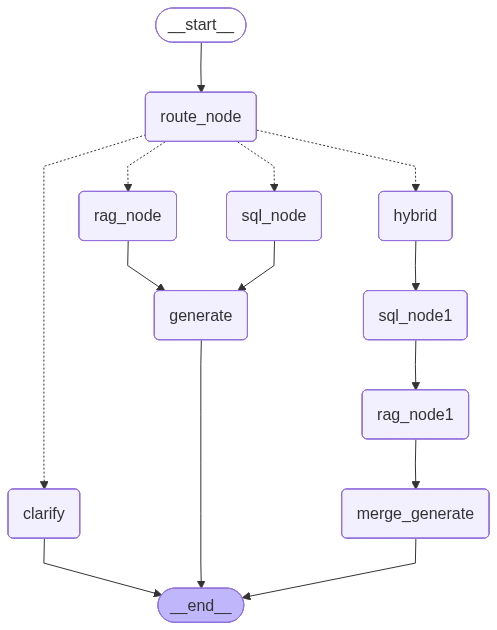

In [23]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [23]:
inputs = {
    "messages": [
        {
            "role": "user",
            "content": "华润三九2023一季度每股收益是多少",
        }
    ]
}

print("=" * 50)

for output in graph.stream(inputs):
    for key, value in output.items():
        print(f"Node '{key}':")
        if isinstance(value, dict) and "messages" in value:
            print(value["messages"][-1])
        else:
            print(value)
    print("-" * 50)

Node 'route_node':
{'query': '华润三九2023一季度每股收益是多少', 'route': 'sql', 'reason': '这是明确的单指标单时期数值查询，可直接通过结构化财务数据库回答', 'missing_slots': [], 'subtasks': [{'type': 'sql', 'goal': '查询华润三九 2023 一季度每股收益'}], 'need_sql': True, 'need_rag': False, 'need_clarification': False}
--------------------------------------------------
Node 'sql_node':
content='华润三九2023年一季度的每股收益（EPS）是 **1.16元**。' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 26, 'prompt_tokens': 2384, 'total_tokens': 2410, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None, 'text_tokens': 26}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': None, 'text_tokens': 2384}}, 'model_provider': 'openai', 'model_name': 'qwen3.5-plus', 'system_fingerprint': None, 'id': 'chatcmpl-eab4341e-d6b4-91a0-8a09-af4e3cc54908', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019d063c-e976-7a03-aae2-e9d8

In [81]:
inputs = {
    "messages": [
        {
            "role": "user",
            "content": "金花股份利润总额是多少",
        }
    ]
}

print("=" * 50)

for output in graph.stream(inputs):
    for key, value in output.items():
        print(f"Node '{key}':")
        if isinstance(value, dict) and "messages" in value:
            print(value["messages"][-1])
        else:
            print(value)
    print("-" * 50)

Node 'route_node':
{'query': '金花股份利润总额是多少', 'route': 'clarify', 'reason': '缺少报告期，无法确定查询的具体财务时间段', 'missing_slots': ['period'], 'subtasks': [], 'need_sql': False, 'need_rag': False, 'need_clarification': True}
--------------------------------------------------
Node 'clarify':
{'final_answer': '请问您想查询金花股份哪个报告期的利润总额？', 'need_clarification': True}
--------------------------------------------------


In [23]:
inputs = {
    "messages": [
        {
            "role": "user",
            "content": "国家医保目录新增的中药产品有哪些",
        }
    ]
}

print("=" * 50)

for output in graph.stream(inputs):
    for key, value in output.items():
        print(f"Node '{key}':")
        if isinstance(value, dict) and "messages" in value:
            print(value["messages"][-1])
        else:
            print(value)
    print("-" * 50)

Node 'route_node':
{'query': '国家医保目录新增的中药产品有哪些', 'route': 'rag', 'reason': '这是知识检索类问题，需要依赖政策或研报等非结构化文本知识库', 'missing_slots': [], 'subtasks': [{'type': 'rag', 'goal': '检索医保目录与相关研报中新增中药产品信息'}], 'need_sql': False, 'need_rag': True, 'need_clarification': False, 'final_answer': ''}
--------------------------------------------------
Node 'rag_node':
{'role': 'assistant', 'content': '行业点评 \n \n敬请参阅最后一页特别声明\n扫码获取更多服务 \n药物能够有效提升在患者中的渗透率。 \n图表7：凭借商保，较高定价的药物能够实现患者渗透率的快速提升 \n \n来源：insight，国金证券研究所 \n中药经典名方申请较多，但政策鼓励创新方向明确。根据国家医保局25 年8 月公告，通过初步审查的中成药共23 种、\n合计25 个产品。今日公示名单，最终入选7 个产品，包括4 个1 类新药以及3 个3 类新药。本次整体入选比例不高，\n主要系经典名方申请较多，且多数未入选。通过初审名单中，共6 个1 类新药，最终入选4 个。12 个3 类中药，最终\n入选3 个。6 个进口中药，无入选。1 个天然药物1.1 类，未入选。 \n图表8：2025 年国家医保目录新增7 个中药产品 \n \n来源：国家医保局，国金证券研究所 \n投资建议 \n西药：建议关注纳入新版医保目录创新药较多/品种重磅的恒瑞医药、百济神州、康方生物、科伦博泰、信达生物等，\n以及大单品首次纳入医保的康诺亚（IL4 单抗）、特宝生物（长效生长激素）等。 \n中成药：建议关注入选新版医保目录的中药产品放量潜力，如华润三九的益气清肺颗粒、以岭药业的芪防鼻通片、方\n盛制药的养血祛风止痛颗粒、康缘药业的玉女煎颗粒/温阳解毒颗粒等。 \n序号\n公司\n药品\n2025年医保目录价格\n2025年医保目录适应症\n用法用量\n注册分类\n1\

In [24]:
import os
import uuid
import gradio as gr

from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, MessagesState, START
from langgraph.checkpoint.mongodb import MongoDBSaver
from langchain_core.messages import AIMessage

DB_URI = "mongodb://localhost:27017"

mongo_ctx = MongoDBSaver.from_conn_string(DB_URI)
checkpointer = mongo_ctx.__enter__()
graph = workflow.compile(checkpointer=checkpointer)

# def respond(message, history, thread_id):
#     config = {
#         "configurable": {
#             "thread_id": thread_id
#         }
#     }

#     last_message = None
#     for chunk in graph.stream(
#         {"messages": [{"role": "user", "content": message}]},
#         config,
#         stream_mode="values"
#     ):
#         last_message = chunk["messages"][-1]

#     return last_message.content if last_message else ""
def respond(message, history, thread_id):
    config = {
        "configurable": {
            "thread_id": thread_id
        }
    }

    final_answer = None
    last_ai_message = None

    for chunk in graph.stream(
        {"messages": [{"role": "user", "content": message}]},
        config,
        stream_mode="values"
    ):
#         if "final_answer" in chunk and chunk["final_answer"]:
        if "final_answer" in chunk:
            final_answer = chunk["final_answer"]

        msgs = chunk.get("messages", [])
        for msg in reversed(msgs):
            if isinstance(msg, AIMessage):
                last_ai_message = msg.content
                break

    if final_answer:
        return final_answer
    if last_ai_message:
        return last_ai_message
    return ""

with gr.Blocks() as demo:
    gr.Markdown("LangGraph + MongoDB Chat")

    thread_id = gr.State(str(uuid.uuid4()))

    chatbot = gr.ChatInterface(
        fn=respond,
        additional_inputs=[thread_id],
    )

demo.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


---GENERATE ANSWER---


In [ ]:
# 金花股份利润总额是多少
# 华润三九每股收益是多少